In [1]:
#Installing necessary libraries

%pip install control > NUL
%pip install matplotlib > NUL
%pip install numpy > NUL

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import control as ctrl
from math import exp, sqrt, sin
import matplotlib.pyplot as plt
import numpy as np

s = ctrl.TransferFunction.s

# Define system parameters
m = 0.462
g = 9.81
d = 0.42
delta = 0.65
r = 0.123
R = 2200
L0 = 0.125
L1 = 0.0241
alpha = 1.2
c_val = 6.811
k = 1885
b = 10.4
tau = 0.03
phi = np.deg2rad(41)

#Equilibrium point values
x_1e = 0.5
x_2e = 0
x_3e = (delta - x_1e)*sqrt( (k*(x_1e-d) - m*g*sin(phi)) / c_val)

#Coefficients from linearisation of gamma
a_3 = (5/(7*m)) * (2*c_val*x_3e)/((delta - x_1e)**2) #x3
a_2 = (5/(7*m))*(-b) #x2
a_1 = (5/(7*m)) * ( (2*c_val*(x_3e**2) ) / ( (delta - x_1e)**3 )  -k) #x1

#Coefficients from linearisation of zeta
b_1 = 1/ (L0 + L1*exp(-alpha*(delta - x_1e)))
b_2 = -R/ (L0 + L1*exp(-alpha*(delta - x_1e)))


#System transfer functions
Gm = a_3/(s**2 - a_2*s - a_1)
Ge = b_1/(s - b_2)
Gs = (1)/((tau*s)+1)

Gme = Gm*Ge

G_open_loop = Gm*Ge*Gs

G_open_loop_poles = ctrl.poles(G_open_loop)

#Pole analysis
for pole in G_open_loop_poles:
  if pole.real < 0:
    print(pole)
  else:
    print(f"{pole} <-- Unstable pole")

(-15158.821860772234+0j)
(-33.33333333333341+0j)
(-22.097673838309735+0j)
(6.018514902008066+0j) <-- Unstable pole


c:\Users\lauka\Documents\Python\Jupyter\ELE2038-Coursework-main\.venv\Lib\site-packages\control\freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


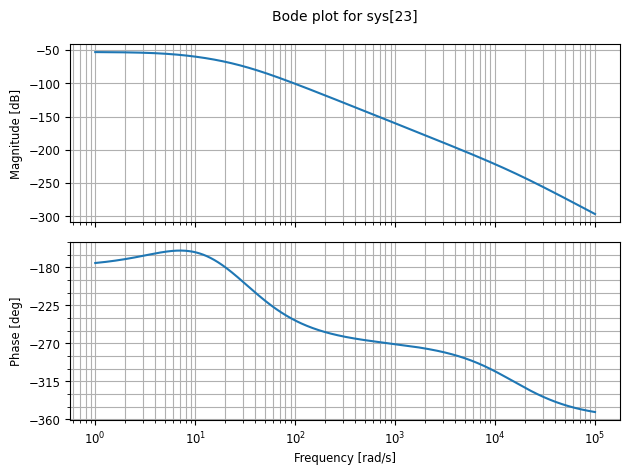

Gain Margin: -53.01 dB
Phase Margin: inf degrees


In [3]:
ctrl.bode(G_open_loop, dB=True, plot=True)
plt.show()

Gain_margin, Phase_margin, w_Gain_margin, w_Phase_margin = ctrl.margin(G_open_loop)
print(f"Gain Margin: {-20*np.log10(Gain_margin):.2f} dB")
print(f"Phase Margin: {Phase_margin:.2f} degrees")

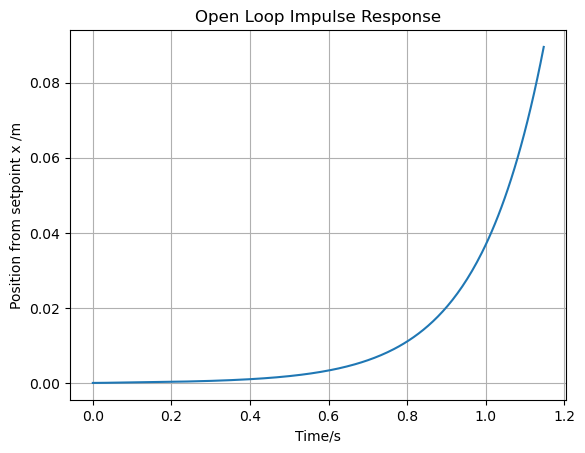

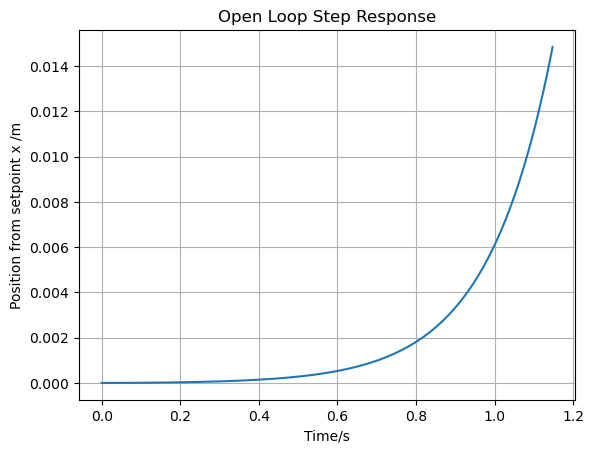

In [5]:
#Responses

ts, Xs = ctrl.impulse_response(G_open_loop)
plt.plot(ts,Xs*0.01)
plt.title(f"Open Loop Impulse Response")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.grid()
plt.show()

ts, Xs = ctrl.step_response(G_open_loop)
plt.plot(ts,Xs*0.01)
plt.title(f"Open Loop Step Response")
plt.xlabel("Time/s")
plt.ylabel("Position from setpoint x /m")
plt.grid()
plt.show()

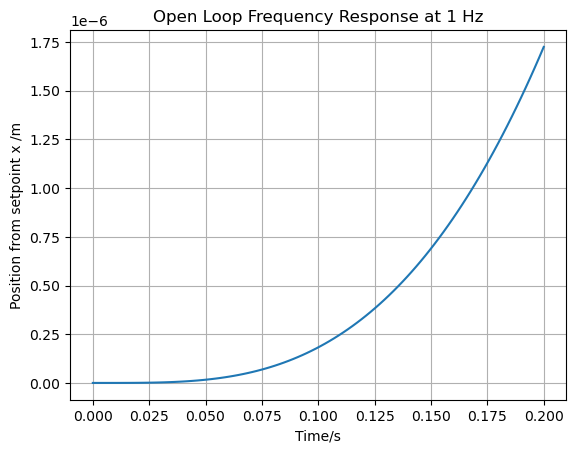

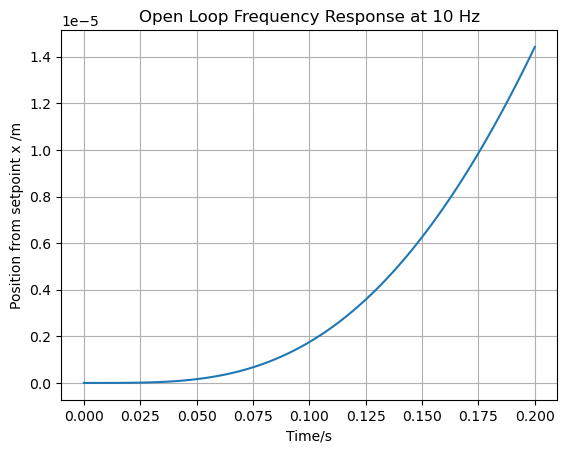

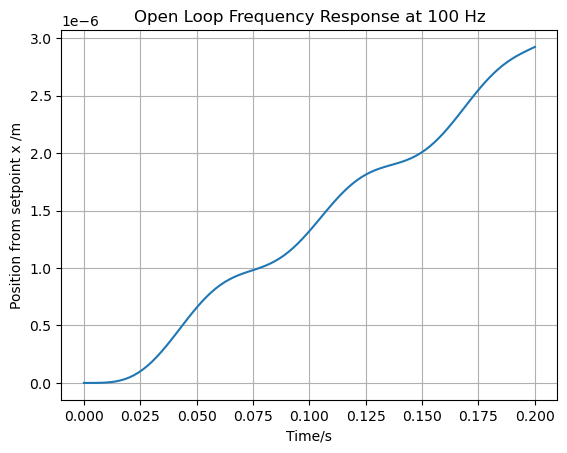

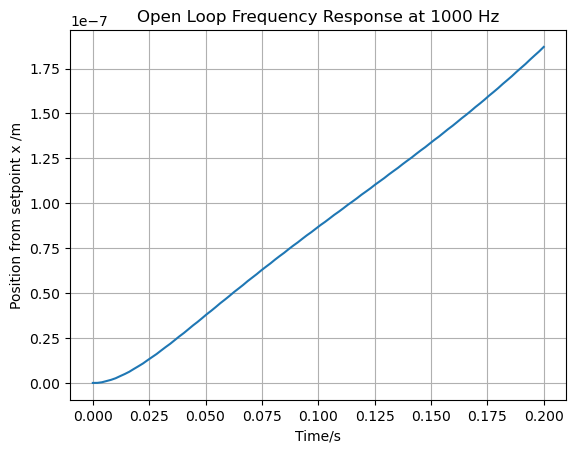

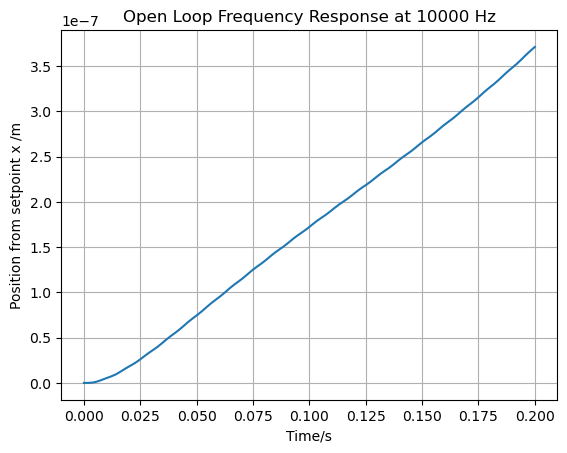

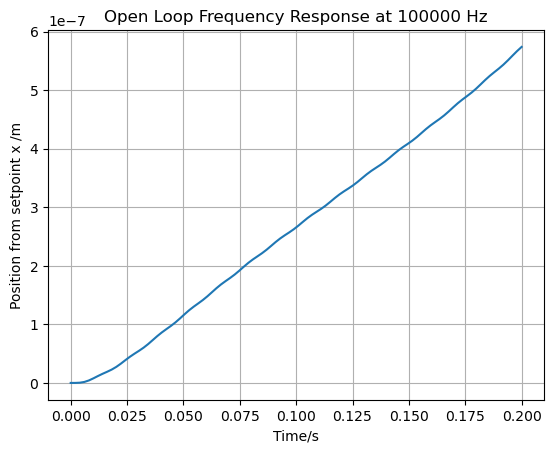

In [8]:
#Frequency response

time = np.linspace(0,0.2,100)
for i in range(0,6):
  frequency = 10**i
  F = np.sin(frequency * time)

  response = ctrl.forced_response(G_open_loop, time, F)
  plt.plot(response.time , response.outputs*0.01)
  plt.title(f"Open Loop Frequency Response at {frequency} Hz")
  plt.xlabel("Time/s")
  plt.ylabel("Position from setpoint x /m")
  plt.grid()
  plt.show()